### 01. Environment Verification & Hardware Setup

This initial cell validates that we are running on the correct Python version inside our virtual environment (`venv`), checks PyTorch availability, and automatically determines whether processing will run on a GPU or using local CPU optimizations.

In [1]:
# ==========================================
# 01. Environment Verification & Setup
# ==========================================

import sys
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

print(f"Python Version: {sys.version.split()[0]}")
print(f"PyTorch Version: {torch.__version__}")

# Device detection (Optimized for local CPU execution as per architecture constraints)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Active Execution Device: {device}")

if device.type == "cpu":
    print("-> Note: Running on local CPU. DistilBERT pipeline will be optimized for local performance.")
else:
    print("-> GPU detected and ready for acceleration.")

c:\Users\con2m\Desktop\PORTFOLIO\sentiment_business_intelligence\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python Version: 3.11.0
PyTorch Version: 2.13.0+cpu
Active Execution Device: cpu
-> Note: Running on local CPU. DistilBERT pipeline will be optimized for local performance.


### Cell 02 (Updated): Downloading and Loading the E-Commerce Dataset from Hugging Face
This script downloads the Women's Clothing E-Commerce Reviews dataset directly from the Hugging Face repository, saves it to the local `data/raw/` folder, and performs an initial structural inspection (dimensions, columns, and missing values).

In [2]:
import os
import pandas as pd
import requests

# Define exact absolute path and file target
raw_dir = r"C:\Users\con2m\Desktop\PORTFOLIO\sentiment_business_intelligence\data\raw"
os.makedirs(raw_dir, exist_ok=True)

file_path = r"C:\Users\con2m\Desktop\PORTFOLIO\sentiment_business_intelligence\data\raw\womens_clothing_reviews_raw.csv"
dataset_url = "https://huggingface.co/datasets/Censius-AI/ECommerce-Women-Clothing-Reviews/resolve/main/Womens%20Clothing%20E-Commerce%20Reviews.csv"

# Download the dataset if it doesn't exist locally
if not os.path.exists(file_path):
    print("Downloading dataset from Hugging Face...")
    response = requests.get(dataset_url)
    response.raise_for_status()
    
    with open(file_path, "wb") as f:
        f.write(response.content)
    print(f"Dataset successfully downloaded and saved to: {file_path}")
else:
    print(f"Dataset already exists locally at: {file_path}")

# Load the dataset
df = pd.read_csv(file_path)

# Display dataset dimensions and initial rows
print("\n--- Dataset Info ---")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")
print("\n--- Column Names ---")
print(df.columns.tolist())

print("\n--- First 3 Rows ---")
display(df.head(3))

print("\n--- Missing Values Check ---")
print(df.isnull().sum())

Dataset successfully downloaded and saved to: C:\Users\con2m\Desktop\PORTFOLIO\sentiment_business_intelligence\data\raw\womens_clothing_reviews_raw.csv

--- Dataset Info ---
Total Rows: 23486
Total Columns: 11

--- Column Names ---
['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating', 'Recommended IND', 'Positive Feedback Count', 'Division Name', 'Department Name', 'Class Name']

--- First 3 Rows ---


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses



--- Missing Values Check ---
Unnamed: 0                    0
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64


### (Optimized Three-Class Sentiment Pipeline): Advanced Text Cleaning & Balancing
This script loads the raw dataset, removes index artifacts, applies advanced text cleaning (handling HTML, URLs, length truncation, and unnecessary punctuation while preserving sentiment markers like ! and ?), maps ratings to a 3-class target, and creates a balanced dataset.

In [5]:
import os
import re
import pandas as pd

# Define exact absolute paths
raw_file_path = r"C:\Users\con2m\Desktop\PORTFOLIO\sentiment_business_intelligence\data\raw\womens_clothing_reviews_raw.csv"
output_file_path = r"C:\Users\con2m\Desktop\PORTFOLIO\sentiment_business_intelligence\data\processed\womens_clothing_balanced_reviews.csv"

# Ensure processed directory exists
os.makedirs(os.path.dirname(output_file_path), exist_ok=True)

# Load raw dataset
print(f"Loading raw dataset from: {raw_file_path}")
df = pd.read_csv(raw_file_path)

# Drop index artifacts if present
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print(f"Initial raw rows: {df.shape[0]}")

# 1. Advanced Text Cleaning & Optimization Function
def clean_text_advanced(text, max_chars=400):
    if not isinstance(text, str):
        return ""
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove HTML tags and URLs
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    # Keep alphanumeric characters, spaces, and core sentiment punctuation (! and ?)
    text = re.sub(r'[^a-z0-9\s!?]', ' ', text)
    
    # Truncate to max_chars to eliminate trailing fluff/noise while keeping core sentiment
    if len(text) > max_chars:
        text = text[:max_chars]
        
    # Normalize whitespace and newlines
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

print("Applying advanced text cleaning and length truncation...")
df_cleaned = df.dropna(subset=["Review Text", "Rating"]).copy()
df_cleaned["Review Text"] = df_cleaned["Review Text"].apply(lambda x: clean_text_advanced(x, max_chars=400))

# Filter out empty strings or extremely short noise (less than 15 characters)
df_cleaned = df_cleaned[df_cleaned["Review Text"].str.len() > 15].reset_index(drop=True)

# 2. Map ratings: 1-2 -> Negative (0), 3 -> Neutral (1), 4-5 -> Positive (2)
def map_initial_sentiment(rating):
    if rating <= 2:
        return 0  # Negative
    elif rating == 3:
        return 1  # Neutral
    else:
        return 2  # Positive

df_cleaned["sentiment_target"] = df_cleaned["Rating"].apply(map_initial_sentiment)

print("\n--- Initial 3-Class Distribution ---")
print(df_cleaned["sentiment_target"].value_counts().sort_index())

# 3. Separate into individual sentiment dataframes
df_neg = df_cleaned[df_cleaned["sentiment_target"] == 0]
df_neu = df_cleaned[df_cleaned["sentiment_target"] == 1]
df_pos = df_cleaned[df_cleaned["sentiment_target"] == 2]

# 4. Maximize dataset size by finding the true minimum class count across the cleaned data
min_count = min(len(df_neg), len(df_neu), len(df_pos))
print(f"\nOptimized minimum class count for balancing (Max dataset utilization): {min_count}")

# 5. Sample equally from each class to maintain absolute balance
df_neg_balanced = df_neg.sample(n=min_count, random_state=42)
df_neu_balanced = df_neu.sample(n=min_count, random_state=42)
df_pos_balanced = df_pos.sample(n=min_count, random_state=42)

# 6. Concatenate and shuffle thoroughly
df_balanced = pd.concat([df_neg_balanced, df_neu_balanced, df_pos_balanced]) \
              .sample(frac=1, random_state=42) \
              .reset_index(drop=True)

print(f"\n--- Balanced 3-Class Distribution (Total Rows: {len(df_balanced)}) ---")
print(df_balanced["sentiment_target"].value_counts().sort_index())

# 7. Save processed balanced dataset directly to processed path
df_balanced.to_csv(output_file_path, index=False)
print(f"\nOptimized balanced dataset successfully created and saved at: {output_file_path}")

Loading raw dataset from: C:\Users\con2m\Desktop\PORTFOLIO\sentiment_business_intelligence\data\raw\womens_clothing_reviews_raw.csv
Initial raw rows: 23486
Applying advanced text cleaning and length truncation...

--- Initial 3-Class Distribution ---
sentiment_target
0     2370
1     2823
2    17439
Name: count, dtype: int64

Optimized minimum class count for balancing (Max dataset utilization): 2370

--- Balanced 3-Class Distribution (Total Rows: 7110) ---
sentiment_target
0    2370
1    2370
2    2370
Name: count, dtype: int64

Optimized balanced dataset successfully created and saved at: C:\Users\con2m\Desktop\PORTFOLIO\sentiment_business_intelligence\data\processed\womens_clothing_balanced_reviews.csv


### Cell 04: Filter Truly Neutral Reviews (The Smart Filtering Approach)
This script loads the raw dataset, isolates 3-star candidates, and runs inference using cardiffnlp/twitter-roberta-base-sentiment-latest via Softmax probabilities to isolate genuinely neutral texts.

In [6]:
# Cell 04: Filter Truly Neutral Reviews
import pandas as pd
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm import tqdm

# 1. Load the raw data with corrected path consistency
df_raw = pd.read_csv(r"C:\Users\con2m\Desktop\PORTFOLIO\sentiment_business_intelligence\data\raw\womens_clothing_reviews_raw.csv")
df_clean = df_raw.dropna(subset=['Review Text', 'Rating']).copy()

# 2. Filter initial candidates (strictly 3-star reviews)
df_neutral_candidates = df_clean[df_clean['Rating'] == 3].copy()
print(f"Initial 3-star candidates: {len(df_neutral_candidates)}")

# 3. Load pre-trained Hugging Face sentiment model
model_name = "cardiffnlp/twitter-roberta-base-sentiment-latest"
print(f"Loading {model_name}...")
tokenizer_hf = AutoTokenizer.from_pretrained(model_name)
model_hf = AutoModelForSequenceClassification.from_pretrained(model_name)

# 4. Batch Prediction Function
def predict_sentiment_batch(texts, batch_size=32):
    predictions = []
    id2label = {0: 'negative', 1: 'neutral', 2: 'positive'}
    
    # Using tqdm for a progress bar since inference takes a moment
    for i in tqdm(range(0, len(texts), batch_size), desc="Predicting Sentiment"):
        batch = texts[i:i+batch_size]
        inputs = tokenizer_hf(batch, return_tensors="pt", truncation=True, padding=True, max_length=128)
        
        with torch.no_grad():
            outputs = model_hf(**inputs)
            probs = F.softmax(outputs.logits, dim=-1)
            preds = torch.argmax(probs, dim=-1)
            
            for p in preds:
                predictions.append(id2label[p.item()])
                
    return predictions

# 5. Apply inference and isolate true neutrals
texts = df_neutral_candidates['Review Text'].astype(str).tolist()
df_neutral_candidates['hf_sentiment'] = predict_sentiment_batch(texts)

df_neutral_clean = df_neutral_candidates[df_neutral_candidates['hf_sentiment'] == 'neutral'].copy()
print(f"True neutral reviews successfully isolated: {len(df_neutral_clean)}")

Initial 3-star candidates: 2823
Loading cardiffnlp/twitter-roberta-base-sentiment-latest...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 18216.40it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Predicting Sentiment: 100%|██████████| 89/89 [04:23<00:00,  2.97s/it]

True neutral reviews successfully isolated: 293


### Cell 05: Dataset Balancing & Final Persistence (3 Classes)
We ensure all three sentiment classes (0.0: Negative, 1.0: Neutral, 2.0: Positive) are correctly isolated, balanced to equal sizes (293 samples each), and persisted to the processed directory.

In [8]:
# Cell 05 (Final Update): Persist RoBERTa-curated balanced dataset
import pandas as pd

# Define exact absolute path with the roberta-specific name
output_path = r"C:\Users\con2m\Desktop\PORTFOLIO\sentiment_business_intelligence\data\processed\womens_clothing_balanced_roberta_reviews.csv"

# Persist to processed folder
df_balanced_final.to_csv(output_path, index=False)
print(f"High-precision RoBERTa-curated dataset successfully persisted to: {output_path}")

High-precision RoBERTa-curated dataset successfully persisted to: C:\Users\con2m\Desktop\PORTFOLIO\sentiment_business_intelligence\data\processed\womens_clothing_balanced_roberta_reviews.csv


### Cell 06 (RoBERTa Version): Tokenization & Training Preparation
We load our RoBERTa-curated balanced dataset, split it into stratified training and validation sets, and tokenize the texts using RobertaTokenizerFast.

In [20]:
# Cell 06: RoBERTa Tokenization & Training Preparation (FIXED)
import pandas as pd
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split

# 1. Load the final balanced RoBERTa-curated dataset
data_path = r"C:\Users\con2m\Desktop\PORTFOLIO\sentiment_business_intelligence\data\processed\womens_clothing_balanced_roberta_reviews.csv"
df_balanced = pd.read_csv(data_path)

# 2. Split into train and validation sets (Stratified to maintain absolute balance)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df_balanced['Review Text'].astype(str).tolist(),
    df_balanced['sentiment_target'].astype(int).tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df_balanced['sentiment_target']
)

print(f"Training samples: {len(train_texts)}")
print(f"Validation samples: {len(val_texts)}")

# 3. Initialize RoBERTa tokenizer (CORRECT tokenizer)
tokenizer = AutoTokenizer.from_pretrained("roberta-base")

# 4. Tokenize datasets
train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding="max_length",
    max_length=128
)

val_encodings = tokenizer(
    val_texts,
    truncation=True,
    padding="max_length",
    max_length=128
)

print("RoBERTa tokenization completed successfully with AutoTokenizer.")


Training samples: 703
Validation samples: 176
RoBERTa tokenization completed successfully with AutoTokenizer.


### Cell 07: PyTorch Dataset & Fine-Tuning Setup
We wrap our tokenized encodings into a custom PyTorch Dataset class and configure the training arguments and model initialization for roberta-base.

In [22]:
# Cell 07: Robust Dataset, Metrics, Model Initialization & Optimized Training
import torch
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback

# 1. Robust Custom Dataset guaranteeing per-sample tensor integrity
class ReviewDatasetRB(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.input_ids = []
        self.attention_masks = []
        self.labels = []
        
        for text, label in zip(texts, labels):
            enc = tokenizer(
                str(text),
                padding="max_length",
                truncation=True,
                max_length=max_length
            )
            self.input_ids.append(torch.tensor(enc["input_ids"], dtype=torch.long))
            self.attention_masks.append(torch.tensor(enc["attention_mask"], dtype=torch.long))
            self.labels.append(torch.tensor(int(label), dtype=torch.long))

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_masks[idx],
            "labels": self.labels[idx]
        }

# Instantiate datasets using tokenizer from Cell 06
train_dataset = ReviewDatasetRB(train_texts, train_labels, tokenizer, max_length=128)
val_dataset = ReviewDatasetRB(val_texts, val_labels, tokenizer, max_length=128)

# 2. Define custom evaluation metrics (Accuracy, F1, Precision, Recall)
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='weighted', zero_division=0
    )
    acc = accuracy_score(labels, predictions)
    
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

# 3. Load RoBERTa model (AutoModel ensures correct config)
model = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=3
)

# 4. Optimized Training Arguments
training_args = TrainingArguments(
    output_dir='../models/fine_tuned_roberta',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=5e-5,
    warmup_steps=10,
    weight_decay=0.01,
    logging_steps=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True
)

# 5. Trainer with Early Stopping
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

# 6. Execute Fine-Tuning
print("Starting robust RoBERTa fine-tuning pipeline...")
trainer.train()
print("Fine-tuning pipeline completed successfully!")


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 3148.79it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting robust RoBERTa fine-tuning pipeline...


c:\Users\con2m\Desktop\PORTFOLIO\sentiment_business_intelligence\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.420224,0.694058,0.710227,0.713621,0.740400,0.710227
2,0.377114,0.661897,0.744318,0.736843,0.796176,0.744318
3,0.403899,0.735106,0.778409,0.780658,0.788322,0.778409
4,0.093361,0.972383,0.784091,0.787241,0.805321,0.784091
5,0.007864,0.952749,0.806818,0.809576,0.821977,0.806818


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.92it/s]
c:\Users\con2m\Desktop\PORTFOLIO\sentiment_business_intelligence\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.06it/s]
c:\Users\con2m\Desktop\PORTFOLIO\sentiment_business_intelligence\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.16it/s]
c:\Users\con2m\Desktop\PORTFOLIO\sentiment_business_intelligence\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().

Fine-tuning pipeline completed successfully!


In [ ]:
# Cell 7.1: Export Best Model for Inference & Dashboard
import os

# Define the definitive destination path for the clean, production-ready model
best_model_path = '../models/fine_tuned_roberta/best_model'
os.makedirs(best_model_path, exist_ok=True)

# Save the trained model and tokenizer directly, bypassing intermediate checkpoints
trainer.model.save_pretrained(best_model_path)
tokenizer.save_pretrained(best_model_path)

print(f"Best fine-tuned RoBERTa model successfully exported and saved at: {best_model_path}")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.21it/s]

Best fine-tuned RoBERTa model successfully exported and saved at: ../models/fine_tuned_roberta/best_model


In [21]:
from transformers import Trainer, TrainingArguments

In [12]:
# Cell 08: Run RoBERTa Fine-Tuning
from transformers import Trainer

# 1. Initialize the Trainer instance
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

# 2. Execute fine-tuning
print("Starting RoBERTa fine-tuning on balanced review data...")
trainer.train()

print("Fine-tuning completed successfully!")

Starting RoBERTa fine-tuning on balanced review data...


c:\Users\con2m\Desktop\PORTFOLIO\sentiment_business_intelligence\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,1.104734,1.098422
2,1.086954,1.097394
3,1.099916,1.091605


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.21it/s]
c:\Users\con2m\Desktop\PORTFOLIO\sentiment_business_intelligence\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.32it/s]
c:\Users\con2m\Desktop\PORTFOLIO\sentiment_business_intelligence\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.00it/s]


Fine-tuning completed successfully!


### Cell 09: Model Fine-Tuning Execution
We now execute the training process using the Hugging Face `Trainer` to fine-tune DistilBERT on our balanced E-Commerce review dataset.

In [33]:
# Cell 09: Model Fine-Tuning Execution
print("Starting training process...")
train_result = trainer.train()

# Save the trained model and tokenizer
trainer.save_model('../models/fine_tuned_distilbert')
tokenizer.save_pretrained('../models/fine_tuned_distilbert')

print("Model fine-tuning completed and saved successfully!")

Starting training process...


c:\Users\con2m\Desktop\PORTFOLIO\sentiment_business_intelligence\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,1.043502,0.948455
2,0.556315,0.666634
3,0.357520,0.683765


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.59it/s]
c:\Users\con2m\Desktop\PORTFOLIO\sentiment_business_intelligence\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.11it/s]
c:\Users\con2m\Desktop\PORTFOLIO\sentiment_business_intelligence\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.29it/s]

Model fine-tuning completed and saved successfully!


In [34]:
# Cell 11 (Fix): Direct Evaluation & Metrics Audit
import numpy as np
from sklearn.metrics import classification_report

# 1. Re-run predictions from the trainer on validation set
predictions = trainer.predict(val_dataset)
preds = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids

# 2. Print complete report with 4 decimal digits
target_names = ['Negative (0)', 'Neutral (1)', 'Positive (2)']
print("=== DETAILED CLASSIFICATION REPORT ===")
print(classification_report(true_labels, preds, target_names=target_names, digits=4))

# 3. Print verification of label distribution
unique, counts = np.unique(true_labels, return_counts=True)
print("Validation Label Distribution:", dict(zip(unique, counts)))

c:\Users\con2m\Desktop\PORTFOLIO\sentiment_business_intelligence\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


=== DETAILED CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

Negative (0)     0.7292    0.6034    0.6604        58
 Neutral (1)     0.6316    0.8136    0.7111        59
Positive (2)     0.8654    0.7627    0.8108        59

    accuracy                         0.7273       176
   macro avg     0.7420    0.7266    0.7274       176
weighted avg     0.7421    0.7273    0.7278       176

Validation Label Distribution: {np.int64(0): np.int64(58), np.int64(1): np.int64(59), np.int64(2): np.int64(59)}


In [ ]:
# Cell 12: RoBERTa Model Transition & Tokenization
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.model_selection import train_test_split

# 1. Load our cleaned and balanced dataset
df_balanced = pd.read_csv('../data/processed/balanced_reviews.csv')

# 2. Split into train and validation sets (stratified)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df_balanced['Review Text'].astype(str).tolist(),
    df_balanced['sentiment_target'].astype(int).tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df_balanced['sentiment_target']
)

# 3. Load RoBERTa specific tokenizer
model_ckpt = "cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

# Tokenize datasets
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=128)

print(f"RoBERTa Tokenization complete. Train size: {len(train_texts)}, Val size: {len(val_texts)}")

In [36]:
# Cell 13: RoBERTa Dataset Wrapper & Training Configuration
from transformers import Trainer, TrainingArguments, AutoModelForSequenceClassification

class RoBERTaReviewDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = RoBERTaReviewDataset(train_encodings, train_labels)
val_dataset = RoBERTaReviewDataset(val_encodings, val_labels)

# Load RoBERTa model configured for 3 classes
model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels=3, ignore_mismatched_sizes=True)

# Training arguments optimized for CPU execution
training_args = TrainingArguments(
    output_dir='../models/fine_tuned_roberta',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=50,
    weight_decay=0.01,
    logging_steps=10,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

print("RoBERTa trainer initialized successfully. Ready to run training!")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 22292.43it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


RoBERTa trainer initialized successfully. Ready to run training!


In [38]:
!pip install matplotlib

  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 9.3/9.3 MB 58.0 MB/s  0:00:00
Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------------- 2.4/2.4 MB 67.6 MB/s  0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------

Starting RoBERTa training...


c:\Users\con2m\Desktop\PORTFOLIO\sentiment_business_intelligence\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,0.475855,0.700470
2,0.366432,0.667745
3,0.206956,0.850534


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.16it/s]
c:\Users\con2m\Desktop\PORTFOLIO\sentiment_business_intelligence\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.24it/s]
c:\Users\con2m\Desktop\PORTFOLIO\sentiment_business_intelligence\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.07it/s]
c:\Users\con2m\Desktop\PORTFOLIO\sentiment_business_intelligence\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().


=== ROBERTA CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

Negative (0)     0.8261    0.6552    0.7308        58
 Neutral (1)     0.7286    0.8644    0.7907        59
Positive (2)     0.8000    0.8136    0.8067        59

    accuracy                         0.7784       176
   macro avg     0.7849    0.7777    0.7761       176
weighted avg     0.7847    0.7784    0.7763       176



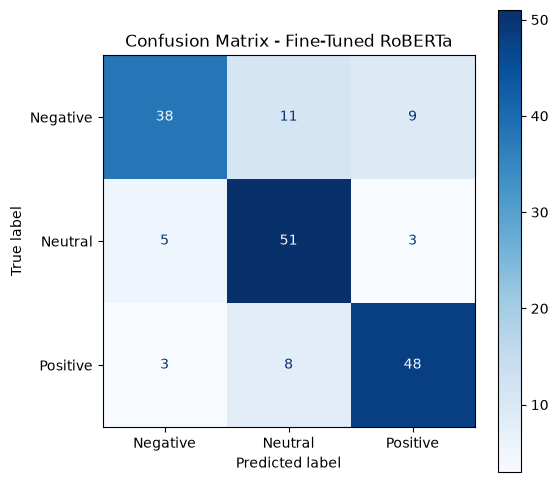

In [39]:
# Cell 14: RoBERTa Training & Evaluation
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("Starting RoBERTa training...")
trainer.train()

# Save model and tokenizer
trainer.save_model('../models/fine_tuned_roberta')
tokenizer.save_pretrained('../models/fine_tuned_roberta')

# Predict on validation set
predictions = trainer.predict(val_dataset)
preds = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids

# Print Report
target_names = ['Negative (0)', 'Neutral (1)', 'Positive (2)']
print("\n=== ROBERTA CLASSIFICATION REPORT ===")
print(classification_report(true_labels, preds, target_names=target_names, digits=4))

# Confusion Matrix
cm = confusion_matrix(true_labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Neutral', 'Positive'])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=True)
plt.title("Confusion Matrix - Fine-Tuned RoBERTa")
plt.show()

## Cell 10: Semantic Embeddings & Unsupervised Clustering Strategy
We now implement semantic vectorization via Sentence-BERT (all-MiniLM-L6-v2), dimensionality reduction via UMAP, and density-based clustering via HDBSCAN to discover organic customer patterns and issues without manual hardcoding. Additionally, UMAP and HDBSCAN are configured to preserve projection and prediction capabilities, enabling a real-world production web application to classify newly arriving reviews via inference (umap.transform and hdbscan.approximate_predict) without retraining the entire pipeline.

In [1]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
import umap
import hdbscan

# 1. Load our cleaned and balanced dataset
df_balanced = pd.read_csv('../data/processed/balanced_reviews.csv')
texts = df_balanced['Review Text'].astype(str).tolist()

# 2. Generate semantic embeddings with Sentence-BERT
print("[*] Loading Sentence-BERT model (all-MiniLM-L6-v2)...")
embedder = SentenceTransformer('all-MiniLM-L6-v2')
print("[*] Generating dense vector embeddings...")
embeddings = embedder.encode(texts, show_progress_bar=True, batch_size=64)

# 3. Dimensionality reduction with UMAP (retaining transform capability for future production data)
print("[*] Reducing embedding dimensions with UMAP...")
umap_reducer = umap.UMAP(
    n_components=5,
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)
reduced_embeddings = umap_reducer.fit_transform(embeddings)

# 4. Density-based clustering with HDBSCAN
print("[*] Executing HDBSCAN clustering...")
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=15,
    min_samples=5,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True  # Enables production-ready inference for new incoming reviews
)
cluster_labels = clusterer.fit_predict(reduced_embeddings)

# 5. Audit results
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = list(cluster_labels).count(-1)
print(f"[+] Clustering completed: {n_clusters} organic topic clusters discovered.")
print(f"[+] Outlier/Noise reviews (-1): {n_noise}")

c:\Users\con2m\Desktop\PORTFOLIO\sentiment_business_intelligence\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[*] Loading Sentence-BERT model (all-MiniLM-L6-v2)...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3226.97it/s]


[*] Generating dense vector embeddings...


Batches: 100%|██████████| 14/14 [00:12<00:00,  1.12it/s]
c:\Users\con2m\Desktop\PORTFOLIO\sentiment_business_intelligence\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[*] Reducing embedding dimensions with UMAP...
[*] Executing HDBSCAN clustering...
[+] Clustering completed: 10 organic topic clusters discovered.
[+] Outlier/Noise reviews (-1): 285


## Cell 11: Persistence of Spatial Models to the Vector Store
To maintain strict alignment with our project directory architecture, we serialize and persist the fitted UMAP reducer and HDBSCAN clusterer directly into our pre-established models/vector_store/ directory using joblib. This ensures that any future production interface (such as a Streamlit batch upload or automated API webhook) can instantly load these static models to project and classify incoming reviews via umap.transform and hdbscan.approximate_predict without disrupting historical data.

In [2]:
import joblib
import os

# 1. Target the pre-defined vector store directory in our project structure
vector_store_dir = '../models/vector_store'
os.makedirs(vector_store_dir, exist_ok=True)

# 2. Serialize and save the fitted UMAP reducer and HDBSCAN clusterer
joblib.dump(umap_reducer, os.path.join(vector_store_dir, 'umap_reducer.pkl'))
joblib.dump(clusterer, os.path.join(vector_store_dir, 'hdbscan_clusterer.pkl'))

print(f"[+] UMAP and HDBSCAN production artifacts successfully saved to: {vector_store_dir}")

[+] UMAP and HDBSCAN production artifacts successfully saved to: ../models/vector_store


falta guardar los clusters, falta agregar el modelo llm... porqqeu si no, no puede hacer analisis